In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("C:/Users/carat/Downloads/loan-recovery.csv")

In [41]:
df.head()

,Borrower_ID,Age,Gender,Employment_Type,Monthly_Income,Num_Dependents,Loan_ID,Loan_Amount,Loan_Tenure,Interest_Rate,...,Collateral_Value,Outstanding_Loan_Amount,Monthly_EMI,Payment_History,Num_Missed_Payments,Days_Past_Due,Recovery_Status,Collection_Attempts,Collection_Method,Legal_Action_Taken
0,BRW_1,59,Male,Salaried,215422,0,LN_1,1445796,60,12.39,...,1.727997e+06,2.914130e+05,4856.88,On-Time,0,0,Partially Recovered,1,Settlement Offer,No
1,BRW_2,49,Female,Salaried,60893,0,LN_2,1044620,12,13.47,...,1.180032e+06,6.652042e+05,55433.68,On-Time,0,0,Fully Recovered,2,Settlement Offer,No
2,BRW_3,35,Male,Salaried,116520,1,LN_3,1923410,72,7.74,...,2.622540e+06,1.031372e+06,14324.61,Delayed,2,124,Fully Recovered,2,Legal Notice,No
3,BRW_4,63,Female,Salaried,140818,2,LN_4,1811663,36,12.23,...,1.145493e+06,2.249739e+05,6249.28,On-Time,1,56,Fully Recovered,2,Calls,No
4,BRW_5,28,Male,Salaried,76272,1,LN_5,88578,48,16.13,...,0.000000e+00,3.918989e+04,816.46,On-Time,1,69,Fully Recovered,0,Debt Collectors,No


In [42]:
df.describe()

,Age,Monthly_Income,Num_Dependents,Loan_Amount,Loan_Tenure,Interest_Rate,Collateral_Value,Outstanding_Loan_Amount,Monthly_EMI,Num_Missed_Payments,Days_Past_Due,Collection_Attempts
count,500.000000,500.000000,500.000000,5.000000e+02,500.00000,500.000000,5.000000e+02,5.000000e+02,500.000000,500.000000,500.000000,500.000000
mean,43.116000,134829.920000,1.476000,1.024907e+06,46.10400,11.192820,6.032240e+05,5.627260e+05,15861.536020,1.912000,70.678000,3.000000
std,12.733217,68969.356746,1.145447,5.907556e+05,18.23706,3.775209,7.457131e+05,4.723581e+05,18709.231315,2.110252,60.211038,2.807805
min,21.000000,15207.000000,0.000000,5.413800e+04,12.00000,5.020000,0.000000e+00,1.571283e+04,261.880000,0.000000,0.000000,0.000000
25%,32.000000,76343.250000,0.000000,4.629848e+05,36.00000,7.907500,0.000000e+00,1.822072e+05,4039.097500,1.000000,4.000000,1.000000
50%,44.000000,134929.500000,1.000000,9.971240e+05,48.00000,10.915000,2.327684e+05,4.133240e+05,9330.170000,2.000000,66.500000,2.000000
75%,53.000000,193086.250000,3.000000,1.557952e+06,60.00000,14.577500,1.111106e+06,8.324787e+05,20439.485000,3.000000,122.250000,4.000000
max,64.000000,249746.000000,3.000000,1.995325e+06,72.00000,17.970000,2.744395e+06,1.932396e+06,127849.230000,12.000000,180.000000,10.000000


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Borrower_ID              500 non-null    object 
 1   Age                      500 non-null    int64  
 2   Gender                   500 non-null    object 
 3   Employment_Type          500 non-null    object 
 4   Monthly_Income           500 non-null    int64  
 5   Num_Dependents           500 non-null    int64  
 6   Loan_ID                  500 non-null    object 
 7   Loan_Amount              500 non-null    int64  
 8   Loan_Tenure              500 non-null    int64  
 9   Interest_Rate            500 non-null    float64
 10  Loan_Type                500 non-null    object 
 11  Collateral_Value         500 non-null    float64
 12  Outstanding_Loan_Amount  500 non-null    float64
 13  Monthly_EMI              500 non-null    float64
 14  Payment_History          5

In [44]:
df.drop(columns=["Borrower_ID","Loan_ID"],inplace=True)

<Axes: xlabel='Recovery_Status', ylabel='count'>

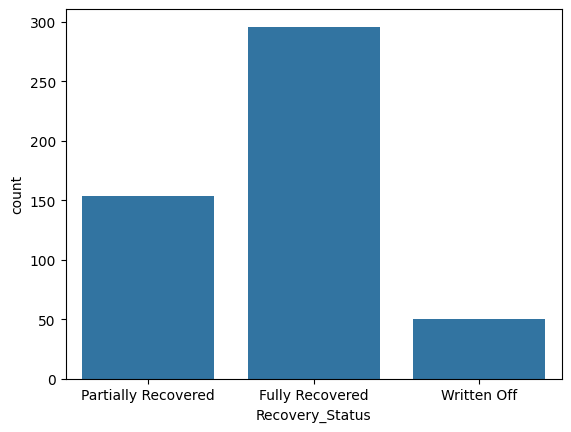

In [45]:
sns.countplot(x = df["Recovery_Status"])

<Axes: xlabel='Payment_History', ylabel='count'>

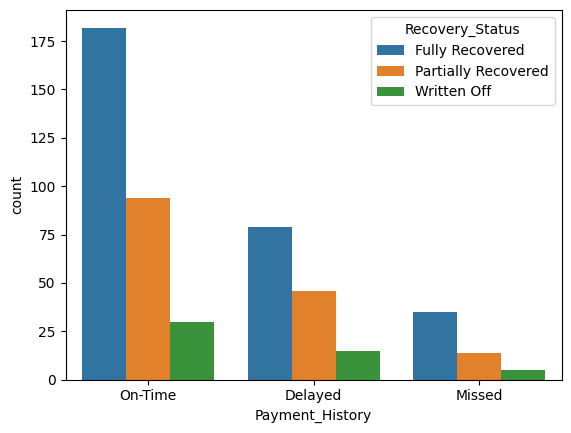

In [46]:
sns.countplot(x=df['Payment_History'],hue=df['Recovery_Status'],hue_order=["Fully Recovered","Partially Recovered","Written Off"])

<Axes: xlabel='Recovery_Status', ylabel='Num_Missed_Payments'>

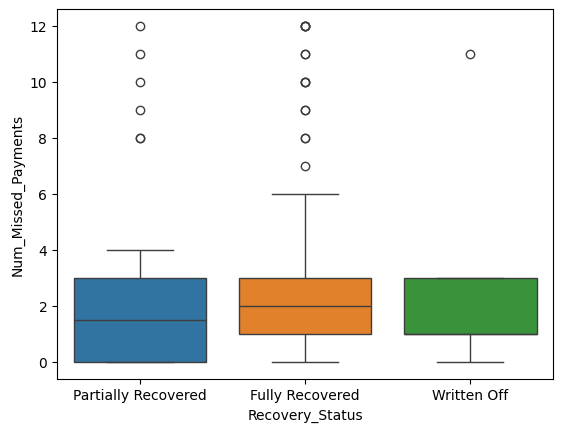

In [47]:
sns.boxplot(x=df['Recovery_Status'],y=df['Num_Missed_Payments'],hue=df['Recovery_Status'])

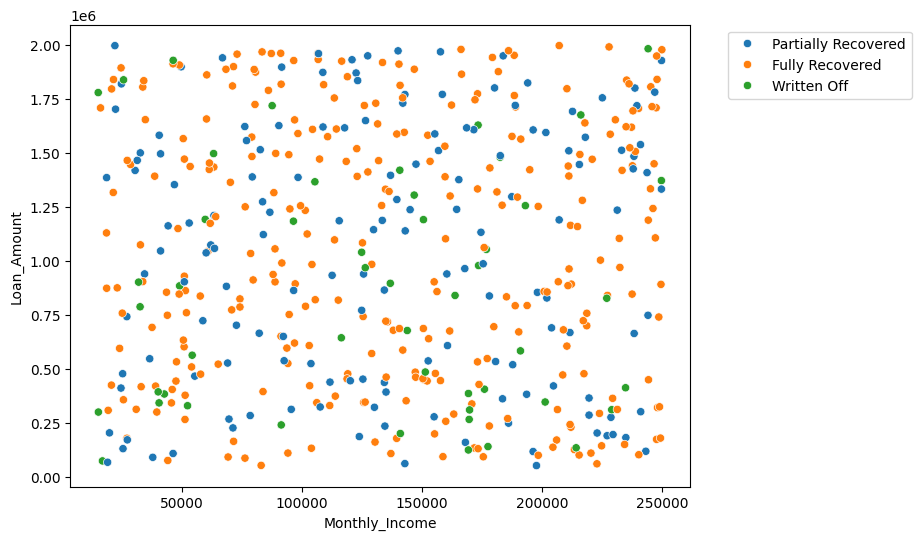

In [48]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["Monthly_Income"],y=df["Loan_Amount"],hue=df["Recovery_Status"])
plt.legend(bbox_to_anchor=(1.05,1),loc="upper left")
plt.show()

In [49]:
df["Debt_to_Income"] = df["Outstanding_Loan_Amount"]/df["Monthly_Income"]
df["EMI_to_Income"] = df["Monthly_EMI"]/df["Monthly_Income"]
df["Collateral_Coverage"] = df["Collateral_Value"]/df["Loan_Amount"]
df["Loan_Utilization"] = df["Outstanding_Loan_Amount"]/df["Loan_Amount"]

In [50]:
features_for_clustering = [
    'Monthly_Income',
    'Loan_Amount',
    'Outstanding_Loan_Amount',
    'Debt_to_Income',
    'EMI_to_Income',
    'Num_Missed_Payments'
]

In [51]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [52]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features_for_clustering])

In [53]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Customer_Segments"] = kmeans.fit_predict(scaled_features)

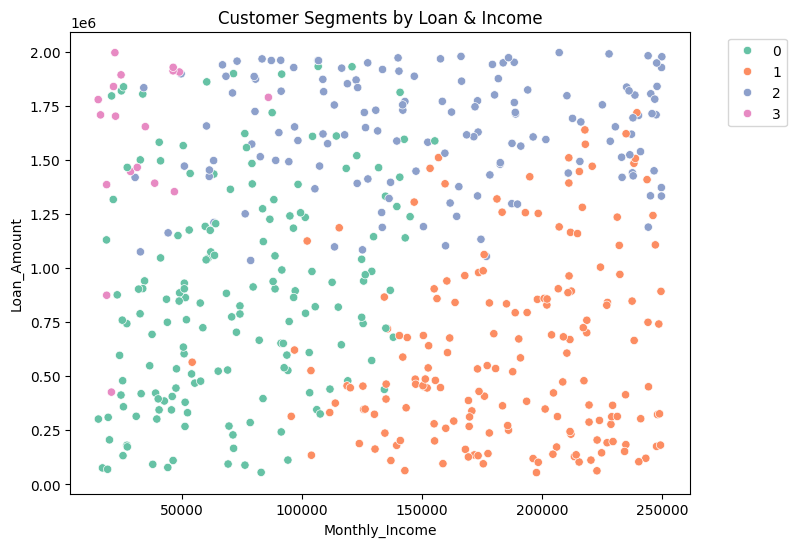

In [54]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["Monthly_Income"],y=df["Loan_Amount"],hue=df["Customer_Segments"],palette = "Set2")
plt.legend(bbox_to_anchor=(1.05,1),loc="upper left")
plt.title("Customer Segments by Loan & Income")
plt.show()

In [55]:
df['Segment_name'] = df['Customer_Segments'].map({
    0: 'Moderate Income, High Loan Burden',
    1: 'High Income, Low Default Risk',
    2: 'Moderate Income, Medium Risk',
    3: 'High Loan, Higher Default Risk'  
})

In [56]:
df['High_risk_flag'] = df['Segment_name'].apply(lambda x: 1 if x in ["Moderate Income, High Loan Burden","High Loan, Higher Default Risk"] else 0)

<Axes: >

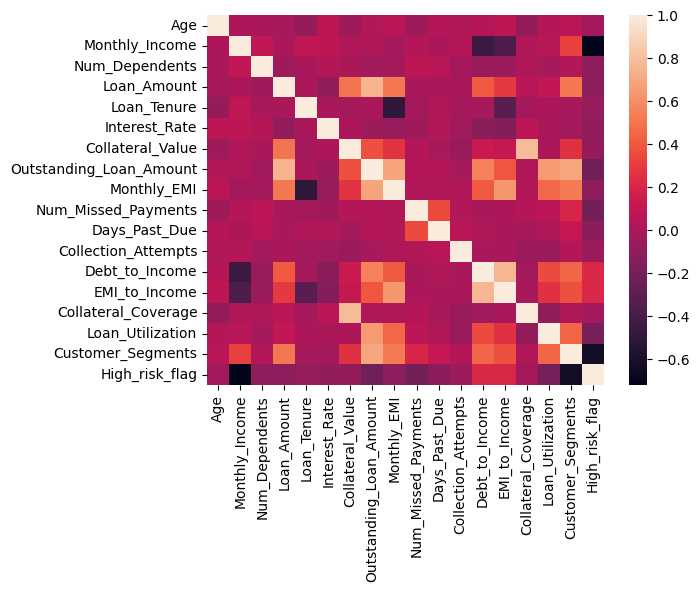

In [57]:
corr = df.corr(numeric_only = True)
sns.heatmap(corr)

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,f1_score
from sklearn.model_selection import cross_val_score

In [59]:
X = df.drop(columns=["Recovery_Status","High_risk_flag","Customer_Segments","Segment_name"])

In [60]:
y = df.iloc[:,-1]

In [61]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [62]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [63]:
preprocessor = ColumnTransformer([
    ("encoder", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("scaler", StandardScaler(), numeric_features)
])

In [64]:
model = RandomForestClassifier(random_state=42,n_estimators=100,class_weight="balanced",max_depth=10)

In [65]:
pipe = Pipeline([
 ("preprocessor",preprocessor),
 ("model",model)   
])

In [66]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Employment_Type',
                                                   'Loan_Type',
                                                   'Payment_History',
                                                   'Collection_Method',
                                                   'Legal_Action_Taken']),
                                                 ('scaler', StandardScaler(),
                                                  ['Age', 'Monthly_Income',
                                                   'Num_Dependents',
                                                   'Loan_Amount', 'Loan_Tenure',
                                                   'Interest_Rate',
                                                   'Collateral_Value',
                                                   'Outstanding_Loan_Amount',
                                                   'Monthly_EMI',
                                                   'Num_Missed_Payments',
                                                   'Days_Past_Due',
                                                   'Collection_Attempts',
                                                   'Debt_to_Income',
                                                   'EMI_to_Income',
                                                   'Collateral_Coverage',
                                                   'Loan_Utilization'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        random_state=42))])

In [67]:
y_pred = pipe.predict(X_test)

In [68]:
accuracy_score(y_test,y_pred)

0.92

In [69]:
precision_score(y_test,y_pred)

0.868421052631579

In [70]:
f1_score(y_test,y_pred)

0.8918918918918919

In [71]:
cross_val_score(pipe,X_train,y_train,cv=5,scoring="accuracy").mean()

np.float64(0.93)

In [73]:
df["Risk_score"] = pipe.predict_proba(X)[:,1]

In [77]:
importances = pipe.named_steps['model'].feature_importances_

In [78]:
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()

In [87]:
top_features = [feature_names[i] for i in importances.argsort()[-10:][::-1]]
top_features

['scaler__Monthly_Income',
 'scaler__EMI_to_Income',
 'scaler__Outstanding_Loan_Amount',
 'scaler__Debt_to_Income',
 'scaler__Monthly_EMI',
 'scaler__Loan_Amount',
 'scaler__Loan_Utilization',
 'scaler__Num_Missed_Payments',
 'scaler__Days_Past_Due',
 'scaler__Collateral_Value']

In [88]:
def classify_risk(score):
    if score >= 0.8:
        return "Critical"
    elif score >= 0.6:
        return "High"
    elif score >= 0.4:
        return "Medium"
    else:
        return "Low"

df["Risk_Level"] = df["Risk_score"].apply(classify_risk)

In [90]:
def generate_recovery_action(row):
    strategies = []

    # Risk-based actions
    if row["Risk_Level"] == "Critical":
        strategies.append("Immediate escalation to collections/legal")
    elif row["Risk_Level"] == "High":
        strategies.append("Restructure loan or reduce EMI")
    elif row["Risk_Level"] == "Medium":
        strategies.append("Send strict reminders and offer payment plan")
    else:
        strategies.append("Maintain regular monitoring")

    # Feature-driven adjustments
    if row["EMI_to_Income"] > 0.5:
        strategies.append("Reduce EMI burden with tenure extension")
    if row["Debt_to_Income"] > 0.8:
        strategies.append("Consider partial settlement options")
    if row["Num_Missed_Payments"] >= 3:
        strategies.append("Increase follow-ups and apply penalties")
    if row["Collateral_Value"] > row["Outstanding_Loan_Amount"]:
        strategies.append("Leverage collateral for secured recovery")

    return "; ".join(strategies)

df["Recovery_Action"] = df.apply(generate_recovery_action, axis=1)

In [100]:
df["Priority_Score"] = df["Risk_score"] * 0.6 + (df["Outstanding_Loan_Amount"] / df["Outstanding_Loan_Amount"].max()) * 0.4
priority_cases = df.sort_values("Priority_Score", ascending=False)